In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

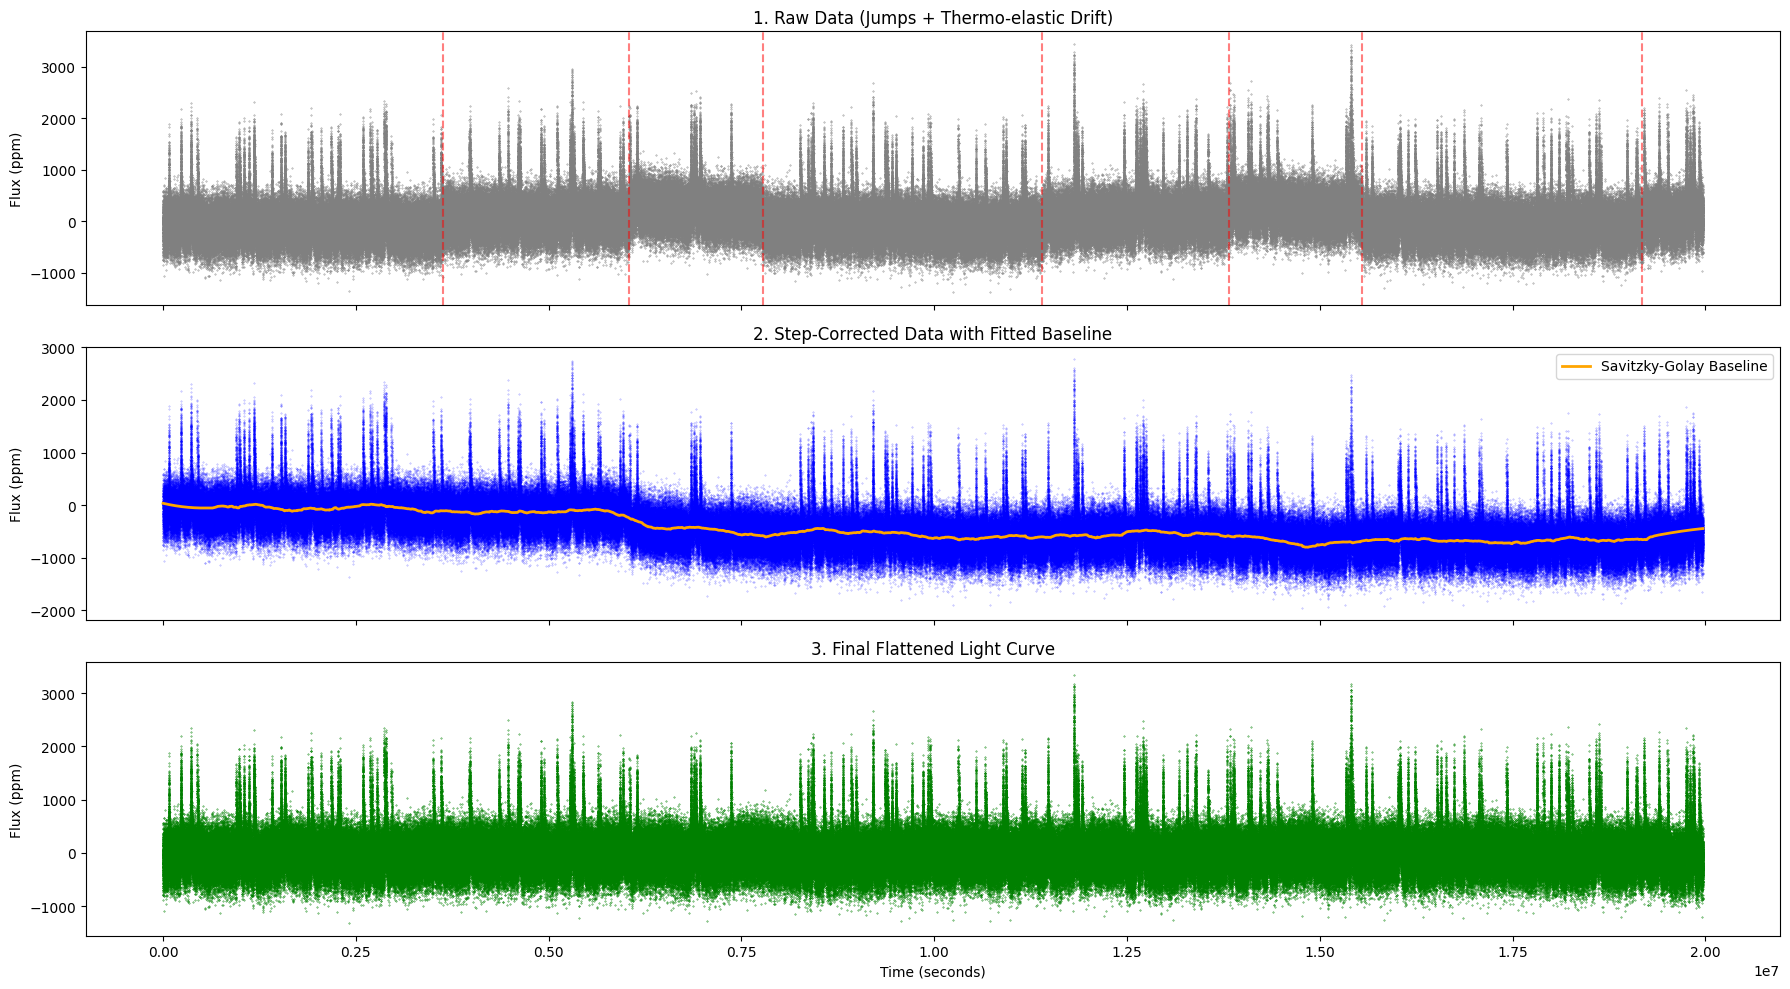

In [ ]:
file_path = "../../data/outputs/sys_1358/0012069449.dat"
data = np.genfromtxt(file_path)
time = data[:, 0]
flux = data[:, 1]

# Known indices where mask updates (jumps) occur
jump_indices = [145140, 241900, 311040, 456180, 552940, 622080, 767220]

def correct_jumps(flux, jumps, window=50):
    """
    Aligns the baseline by calculating the median flux just before 
    and just after a known jump index, then shifting all subsequent data.
    """
    flux_corrected = flux.copy()
    
    for idx in jumps:
        # Ensure the calculation window doesn't go out of bounds
        if idx < window or idx + window > len(flux_corrected):
            continue
            
        # Calculate local medians to determine the step magnitude
        median_before = np.median(flux_corrected[idx - window : idx])
        median_after = np.median(flux_corrected[idx : idx + window])
        
        # Calculate the necessary shift to align the segments
        offset = median_before - median_after
        
        # Apply the scalar shift to the rest of the array
        flux_corrected[idx:] += offset
        
    return flux_corrected

def correct_slope(time, flux, bin_size=100, original_window=90001, polyorder=2):
    """
    Fits a low-frequency baseline instantly by downsampling the data, 
    applying the filter to the tiny array, and interpolating the curve back.
    """
    # 1. Downsample the data (e.g., take every 100th point)
    # This reduces a 500,000 point array to a 5,000 point array.
    t_down = time[::bin_size]
    f_down = flux[::bin_size]
    
    # 2. Scale down the window length appropriately
    small_window = original_window // bin_size
    if small_window % 2 == 0: 
        small_window += 1
    small_window = max(3, min(small_window, len(f_down) - 1))
    
    # 3. Apply the filter to the tiny array
    baseline_down = savgol_filter(f_down, window_length=small_window, polyorder=polyorder)
    
    # 4. Interpolate that smooth curve back up to the full-resolution time array
    baseline_full = np.interp(time, t_down, baseline_down)
    
    # 5. Flatten the full light curve
    flux_detrended = flux - baseline_full
    
    return flux_detrended, baseline_full

# 1. Apply the jump correction just like before
flux_no_jumps = correct_jumps(flux, jump_indices)

# 2. Apply the slope correction
flux_final, fitted_baseline = correct_slope(time, flux_no_jumps, bin_size=100, original_window=50001)

# 3. Plotting the pipeline
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Top: Raw Data
axes[0].scatter(time, flux, s=0.1, color='gray')
axes[0].set_title("1. Raw Data (Jumps + Thermo-elastic Drift)")
for j in jump_indices:
    if j < len(time):
        axes[0].axvline(time[j], color='red', linestyle='--', alpha=0.5)

axes[0].set_ylabel("Flux (ppm)")

# Middle: Jumps Corrected + Overlay of Slope Fit
axes[1].scatter(time, flux_no_jumps, s=0.1, color='blue', alpha=0.4)
axes[1].plot(time, fitted_baseline, color='orange', linewidth=2, label="Savitzky-Golay Baseline")
axes[1].set_title("2. Step-Corrected Data with Fitted Baseline")
axes[1].legend()
axes[1].set_ylabel("Flux (ppm)")

# Bottom: Fully Detrended
axes[2].scatter(time, flux_final, s=0.1, color='green')
axes[2].set_title("3. Final Flattened Light Curve")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Flux (ppm)")
plt.tight_layout()
plt.show()

The Plato instrument will drift off target as it is measuring an object. Every certain amount of time, it will correct for this drift by suddenly jumping in position. This creates large changes in the flux, as well as a slop in the flux (rather than flat distribution). We must correct for this to prevent from biassing our estimates. We do so by reading in where these jumps occur, patching them together, and then correcting for the slope drift. We correct for the slope drift by running a fit with a filter to track the evolution of the flux in a window over time. We then subtract this to get a drift-correction.  

In [ ]:
df_combined = pd.read_csv("../../data/input_labels/paired_simulation_labels_combined.csv")

In [ ]:
print("Starting batch drift correction...")

# Filter only the rows that have drift
drift_systems = df_combined[df_combined['drift'] != 'none']

processed_count = 0


for index, row in drift_systems.iterrows():
    sys_id = row['system_id']

    target_dir = f"outputs/{sys_id}"
    
    # Find the original .dat file (ignoring any already corrected ones)
    search_pattern = os.path.join(target_dir, "*.dat")

    for f in glob.glob(search_pattern):
        if "_driftcorrected" in f:
            print("Already completed")
            continue
    
    dat_files = [f for f in glob.glob(search_pattern) if "_driftcorrected" not in f]
    
    if not dat_files:
        print(f"  Warning: No valid .dat file found for {sys_id}")
        continue
        
    original_filepath = dat_files[0]
    
    try:
        # 1. Load the data (now explicitly grabbing all 3 columns)
        data = np.genfromtxt(original_filepath)

        print(f"Loaded data for system {sys_id}")
        time = data[:, 0]
        flux = data[:, 1]
        flags = data[:, 2]
        
        # 2. Extract jump indices directly from the flag column
        # np.where returns a tuple, so we grab the first element [0] and convert to list
        jump_indices = list(np.where(flags != 0)[0])
        
        # 3. Apply the correction pipeline
        flux_no_jumps = correct_jumps(time, flux, jump_indices)
        flux_final = correct_slope(time, flux_no_jumps, bin_size=100, original_window=50001)
        
        # 4. Save to the new file
        # Reconstruct the array with original time, NEW flux, and original flags.
        corrected_data = np.column_stack((time, flux_final, flags))
        
        # Build the new filename
        base_name = os.path.splitext(os.path.basename(original_filepath))[0]
        new_filepath = os.path.join(target_dir, f"{base_name}_driftcorrected.dat")
        
        # Save it formatting as standard scientific floats separated by tabs
        np.savetxt(new_filepath, corrected_data, fmt='%.8e', delimiter='\t')
        
        processed_count += 1
        if processed_count % 50 == 0:
            print(f"  Processed {processed_count} files...")
            
    except Exception as e:
        print(f"  Error processing {sys_id}: {e}")

print(f"\nDone! Successfully created {processed_count} drift-corrected light curves.")

Starting batch drift correction...
Loaded data for system sys_1397
Loaded data for system sys_1398
Loaded data for system sys_1399
Loaded data for system sys_1400
Loaded data for system sys_1401
Loaded data for system sys_1402
Already completed
Loaded data for system sys_1403
Already completed
Loaded data for system sys_1404
Already completed
Loaded data for system sys_1405
Already completed
Loaded data for system sys_1406
Already completed
Loaded data for system sys_1407
Loaded data for system sys_1408
Loaded data for system sys_1409
Loaded data for system sys_1410
Loaded data for system sys_1411
Loaded data for system sys_1412
Loaded data for system sys_1413
Already completed
Loaded data for system sys_1414
Loaded data for system sys_1415
Loaded data for system sys_1416
Loaded data for system sys_1417
Loaded data for system sys_1418
Loaded data for system sys_1419
Loaded data for system sys_1420
Loaded data for system sys_1421
Loaded data for system sys_1422
Loaded data for system sy

KeyboardInterrupt: 